Brianna Lannerd <br>
10/03/2026 <br>
Lab 06: Spinning and Rolling Objects <br>
Disclaimer: For Part A, code from the code module lesson was incorporated. AI was used throughout the lab for trouble shooting and plotting.

In [39]:
#Import Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt

Part A- The Physical Pendulum

In [40]:
#Define gravitational constant
g = 9.81 #m/s^2

#function to perform a single Euler-Cromer step for rotation
def rotate_step(theta, omega, torque, I, dt):
    """Euler-Cromer step for rotation, from the lesson."""
    alpha = torque / I
    omega = omega + alpha * dt
    theta = theta + omega * dt
    return theta, omega


In [41]:
#Initial parameters for the pendulum
m = 1.0
rod_length = 1.0
d = rod_length / 2

#Equations for the moment of inertia, angular frequency, and small-angle period of the pendulum
I_rod = m * rod_length**2 / 3
Omega = np.sqrt(m * g * d / I_rod)
small_period = 2 * np.pi / Omega

# Part A: Section 1
#function to simulate the pendulum motion using the Euler-Cromer method
def pendulum(theta0, dt=0.001, duration=12.0):
    t = np.arange(round(duration / dt) + 1) * dt #time array
    theta = np.zeros(len(t)) #store the angle at each time step
    omega = np.zeros(len(t)) #store the angular velocity at each time step
    theta[0] = theta0 #initial angle
    for i in range(len(t) - 1): 
        torque = -m * g * d * np.sin(theta[i]) #calculate the torque at the current angle
        theta[i+1], omega[i+1] = rotate_step(theta[i], omega[i], torque, I_rod, dt) #perform the Euler-Cromer step to update the angle and angular velocity
    energy = 0.5 * I_rod * omega**2 + m * g * d * (1 - np.cos(theta)) #calculate the total energy at each time step
    return t, theta, omega, energy

#function to measure the period of the pendulum motion by interpolating downward crossings of theta=0
def measured_period(t, theta):
    # Interpolate downward crossings of theta=0; successive ones span a period.
    indices = np.where((theta[:-1] > 0) & (theta[1:] <= 0))[0] #find indices where theta crosses zero from above
    crossings = []
    for i in indices: 
        fraction = theta[i] / (theta[i] - theta[i+1]) #calculate the fraction of the time step at which the crossing occurs
        crossings.append(t[i] + fraction * (t[i+1] - t[i])) #append the interpolated crossing time to the list
    return np.mean(np.diff(crossings)) #calculate the average period from the differences between successive crossings




Small-angle predicted period: 1.637947 s
theta0=0.3: measured period=1.647207 s; maximum energy deviation=0.191%
theta0=2.5: measured period=2.691119 s; maximum energy deviation=0.151%


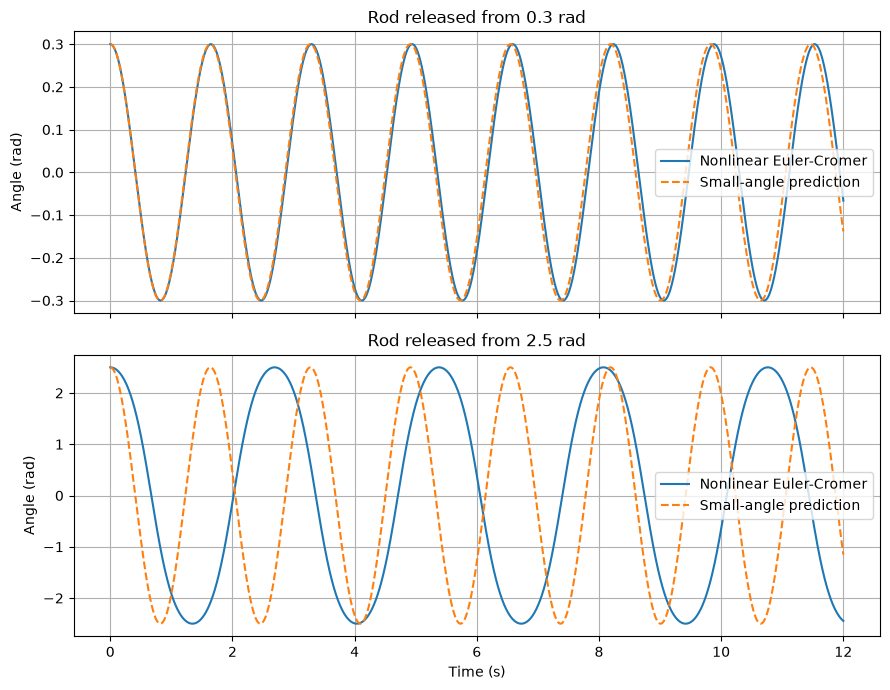

dt=0.0020 s: period=2.691123 s, max relative energy deviation=0.003032
dt=0.0010 s: period=2.691119 s, max relative energy deviation=0.001515
dt=0.0005 s: period=2.691118 s, max relative energy deviation=0.000757


In [42]:
#Part A, section 2 and section 3
#Plotting the results of the pendulum simulation for two different initial angles, and printing the measured periods and energy deviations
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
print(f"Small-angle predicted period: {small_period:.6f} s")
for ax, theta0 in zip(axes, [0.3, 2.5]):
    t, theta, omega, energy = pendulum(theta0)
    period = measured_period(t, theta)
    ax.plot(t, theta, label="Nonlinear Euler-Cromer")
    ax.plot(t, theta0 * np.cos(Omega * t), "--", label="Small-angle prediction")
    ax.set_title(f"Rod released from {theta0} rad")
    ax.set_ylabel("Angle (rad)")
    ax.grid()
    ax.legend()
    print(f"theta0={theta0}: measured period={period:.6f} s; "
          f"maximum energy deviation={np.max(np.abs(energy-energy[0]))/energy[0]:.3%}")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Check that reducing the time step reduces the energy error.
for dt in [0.002, 0.001, 0.0005]:
    t, theta, omega, energy = pendulum(2.5, dt)
    print(f"dt={dt:.4f} s: period={measured_period(t, theta):.6f} s, "
          f"max relative energy deviation={np.max(np.abs(energy-energy[0]))/energy[0]:.6f}")

Part A: Section 4: At large amplitude, the real period is longer than the small-angle prediction. The restoring torque depends on sin of theta, which is smaller in magnitude than the approximation of theta as seen on the graph, so the pendulum takes longer to complete a swing. 

Part B- The Rolling Race

In [43]:
ramp_length = 3.0
incline = np.deg2rad(30)
radius = 0.10
mass = 1.0
#Part B: Section 1- Simulate 3 bodies
shapes = {"Hoop": 1.0, "Disk": 0.5, "Solid sphere": 0.4}

def rolling_accel(theta_incline, c, g=9.81):
    """Rolling acceleration, from the lesson; c = I/(m R^2)."""
    return g * np.sin(theta_incline) / (1 + c)

def roll(c, dt=0.001):
    a = rolling_accel(incline, c)
    t, s, v = [0.0], [0.0], [0.0]
    while s[-1] < ramp_length:
        remaining = ramp_length - s[-1]
        # Stable positive solution of remaining = v*h + 0.5*a*h^2.
        time_to_finish = 2 * remaining / (v[-1] + np.sqrt(v[-1]**2 + 2*a*remaining))
        step = min(dt, time_to_finish)
        s_new = s[-1] + v[-1]*step + 0.5*a*step**2
        if time_to_finish <= dt:
            s_new = ramp_length
        t.append(t[-1] + step)
        s.append(s_new)
        v.append(v[-1] + a*step)
    return np.array(t), np.array(s), np.array(v)

race = {}





Hoop: finish=1.564124 s; analytical=1.564124 s
Disk: finish=1.354571 s; analytical=1.354571 s
Solid sphere: finish=1.308640 s; analytical=1.308640 s


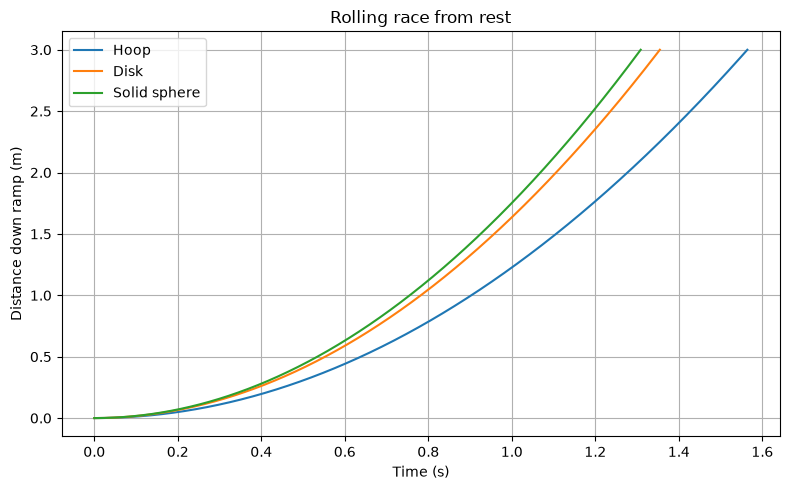

Finishing order: Solid sphere → Disk → Hoop


In [44]:
#Part B: Section 2- Race Them
plt.figure(figsize=(8, 5))
for name, c in shapes.items():
    t, s, v = roll(c)
    race[name] = (t, s, v)
    predicted = np.sqrt(2*ramp_length / rolling_accel(incline, c))
    print(f"{name}: finish={t[-1]:.6f} s; analytical={predicted:.6f} s")
    assert np.isclose(t[-1], predicted, rtol=1e-10)
    plt.plot(t, s, label=name)
plt.xlabel("Time (s)")
plt.ylabel("Distance down ramp (m)")
plt.title("Rolling race from rest")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
print("Finishing order:", " → ".join(sorted(race, key=lambda name: race[name][0][-1])))

All of the curves start at the same point but they slowly diverge from the same path as they start to accelerate. This is from the difference in inertia. The solid sphere finishes first, then the disk, then the hoop.

In [45]:
#Part B: Section 3 -Verify Energy Partition
# Energy partition for the disk, with zero PE at the ramp bottom.
t, s, v = race["Disk"]
c = shapes["Disk"]
I_disk = c * mass * radius**2
omega = v / radius
KE_trans = 0.5 * mass * v**2
KE_rot = 0.5 * I_disk * omega**2
PE = mass * g * (ramp_length - s) * np.sin(incline)
E_total = KE_trans + KE_rot + PE
print(f"Disk rotational fraction of final KE: {KE_rot[-1]/(KE_trans[-1]+KE_rot[-1]):.6f}")
print(f"Maximum relative total-energy deviation: {np.max(np.abs(E_total-E_total[0]))/E_total[0]:.3e}")
assert np.allclose(E_total, E_total[0], rtol=1e-10)

Disk rotational fraction of final KE: 0.333333
Maximum relative total-energy deviation: 2.076e-14


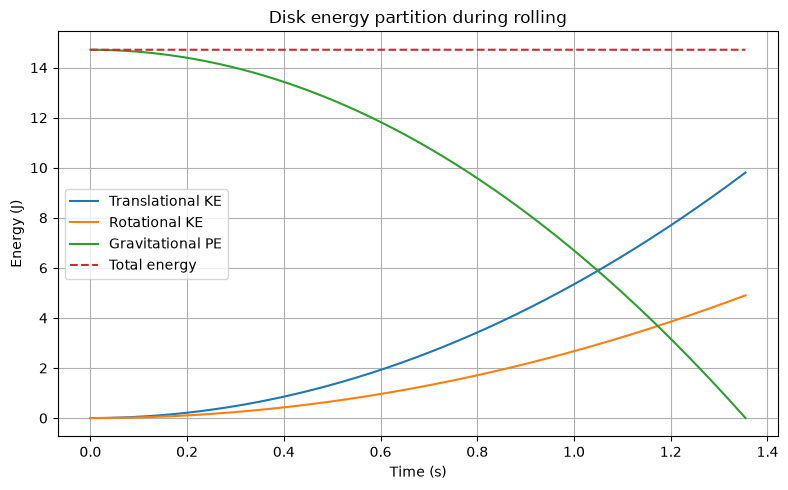

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(t, KE_trans, label="Translational KE")
plt.plot(t, KE_rot, label="Rotational KE")
plt.plot(t, PE, label="Gravitational PE")
plt.plot(t, E_total, "--", label="Total energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Disk energy partition during rolling")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


The total energy stays a flat horizontal line which is expected since energy should be conserved in this system because certain assumptions were made that should lead to no energy loss. The gravitational potential energy decreases which is also expected since the objects are moving from a height above the ground towards the ground.

Part B: Section 4- Analysis: The sphere finishes first then the disk finishes then the hoop finishes. The way their mass is distributed impacts their inertai which means their rotational accelerations are different. Since slipping is not facored in, the acceleration equation is a = (g*sin (theta))/(1+c). C is depended on I which is different for all of these objects. Mass cancels because both the gravitational driving force and resistance to acceleration both increase as mass increases. The value for c also scales with radius squared, so the finishing placements of the objects are determined by their geometry regardless of mass or radius.

Part C - Angular Momentum Conservation

In [47]:
#Part C: Section 1 - Model of a torque free spinning body
dt = 0.001
t = np.arange(10001) * dt
I0 = 2.0
omega0 = 3.0
L0 = I0 * omega0

#Part C: Section 2- I is reduced
fraction = np.clip((t - 4.0) / 1.0, 0.0, 1.0)
I = I0 * (1 - 0.5 * fraction)
omega = L0 / I
angular_momentum = I * omega
KE = 0.5 * I * omega**2



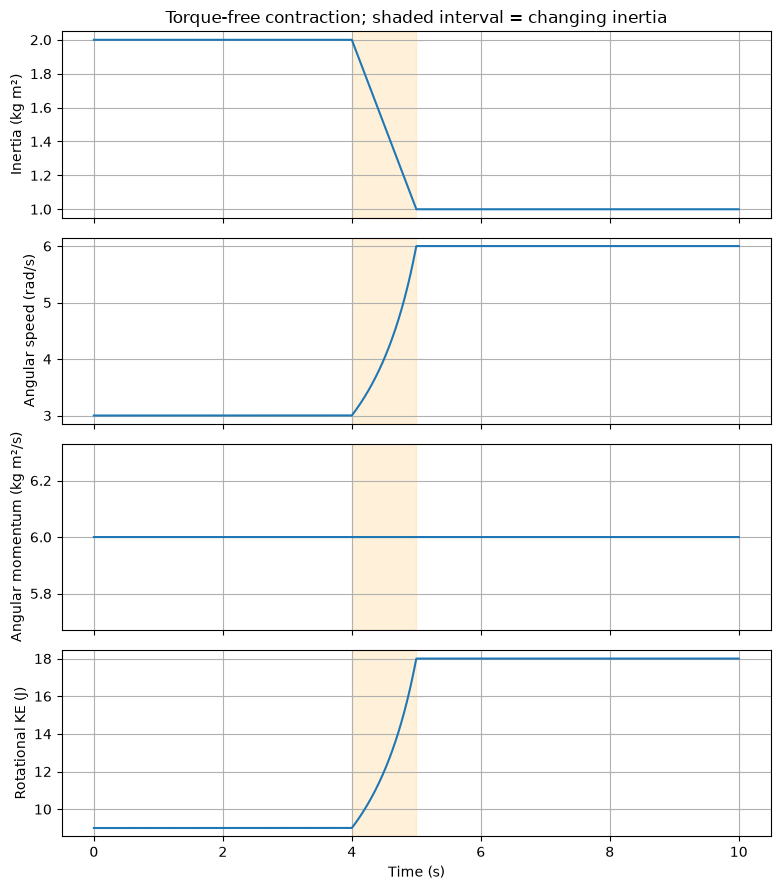

Inertia: 2.0 → 1.0 kg m²
Angular speed: 3.0 → 6.0 rad/s
Angular momentum: 6.0 → 6.0 kg m²/s
Rotational KE: 9.0 → 18.0 J
Internal work needed: 9.0 J
Maximum angular-momentum deviation: 8.882e-16


In [48]:
#Part C: Section 3: Ploting I(t), w(t), L(t) and rotational KE(t)
fig, axes = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
for ax, values, label in zip(axes, [I, omega, angular_momentum, KE],
                           ["Inertia (kg m²)", "Angular speed (rad/s)",
                            "Angular momentum (kg m²/s)", "Rotational KE (J)"]):
    ax.plot(t, values)
    ax.axvspan(4, 5, color="orange", alpha=0.15)
    ax.set_ylabel(label)
    ax.grid()
axes[0].set_title("Torque-free contraction; shaded interval = changing inertia")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()
print(f"Inertia: {I[0]:.1f} → {I[-1]:.1f} kg m²")
print(f"Angular speed: {omega[0]:.1f} → {omega[-1]:.1f} rad/s")
print(f"Angular momentum: {angular_momentum[0]:.1f} → {angular_momentum[-1]:.1f} kg m²/s")
print(f"Rotational KE: {KE[0]:.1f} → {KE[-1]:.1f} J")
print(f"Internal work needed: {KE[-1]-KE[0]:.1f} J")
print(f"Maximum angular-momentum deviation: {np.max(np.abs(angular_momentum-L0)):.3e}")
assert np.allclose(angular_momentum, L0, rtol=1e-12)
assert np.isclose(omega[-1], 2*omega0)
assert np.isclose(KE[-1], 2*KE[0])

Part C: Section 4- L stays constant and L=Iw, which means when I decreases, w must increase by the same scale. When Rotational kinetic energy increases because KE=L^2/(2*I) so if I decreases, then KE increases. The extra energy comes from the word done when pulling the arms inward. THe skaters internal energy is converted to kinetic energy. If you account for the source of energy, then total energy is conserved.


Part C: Section 5-
The three conservation law diagnostics are Energy, LInear momentum, and Angular momentum. FOr energy, if you have an undamped pendulum and the mechanical energy of the system increases, then it is possible the approximation method is not good enough. For linear momentum, if you have a collision between two objects and the total momentum changes, it shows a violation of newtons law that they must act equal and opposite on the other. If angular momentum changes in a system without torque or an external force, it could indicate that the relationship between angular velocity and inertia is incorrect if one is changing and the other isnt changing in the opposite way.

Bonus Challenge - Rolling Meets Collisions

In [49]:
#Initial parameters for the collision
disk_mass = mass
#Chosen randomnly
block_mass = 3.25
# Makes collision perfectly elastic
restitution = 1.0
#Motion before impact
v_in = race["Disk"][2][-1]
w_in = v_in / radius
#velocities of both objects after impact
v_disk = (disk_mass - restitution*block_mass) / (disk_mass+block_mass) * v_in
v_block = (1+restitution) * disk_mass / (disk_mass+block_mass) * v_in
w_after = w_in
#Calculates linear momentum and Kinetic Energy
p_before = disk_mass * v_in
p_after = disk_mass * v_disk + block_mass * v_block
E_before = 0.5*disk_mass*v_in**2 + 0.5*I_disk*w_in**2
E_after = 0.5*disk_mass*v_disk**2 + 0.5*block_mass*v_block**2 + 0.5*I_disk*w_after**2
#Reports calculation results
print(f"Incoming disk speed: {v_in:.6f} m/s")
print(f"Outgoing disk speed: {v_disk:.6f} m/s")
print(f"Outgoing block speed: {v_block:.6f} m/s")
print(f"Disk spin before/after: {w_in:.6f} / {w_after:.6f} rad/s")
print(f"Linear momentum before/after: {p_before:.6f} / {p_after:.6f} kg m/s")
print(f"Total KE before/after: {E_before:.6f} / {E_after:.6f} J")





Incoming disk speed: 4.429447 m/s
Outgoing disk speed: -2.345001 m/s
Outgoing block speed: 2.084446 m/s
Disk spin before/after: 44.294469 / 44.294469 rad/s
Linear momentum before/after: 4.429447 / 4.429447 kg m/s
Total KE before/after: 14.715000 / 14.715000 J


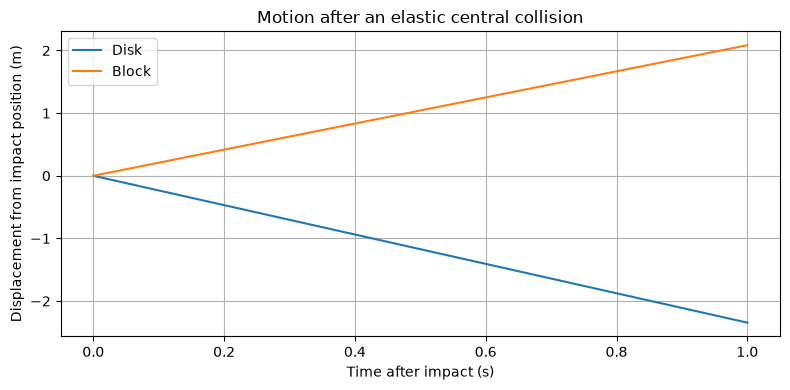

In [ ]:
#Plot the motion
post_t = np.linspace(0, 1, 501)
plt.figure(figsize=(8, 4))
plt.plot(post_t, v_disk*post_t, label="Disk")
plt.plot(post_t, v_block*post_t, label="Block")
plt.xlabel("Time after impact (s)")
plt.ylabel("Displacement from impact position (m)")
plt.title("Motion after an elastic central collision")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The disk does keep spinning because the force from the collision only acts through the center of the mass whcih means no torque is produced. The model omits things like any possible air resistance, friction between the objects and the floor, and any torque during contact that could change the disks's spin. Collisions in general also in the real world lose kinetic energy to heat and sound.f